# Photon Point Detectors (F5 / Next-Event Estimator)

This notebook demonstrates OpenMC's **point detector** tallies — the equivalent of MCNP's
F5 tally — for **photons**.

A point detector estimates the flux at a point $\mathbf{r}_d$ with a *next-event estimator*:
at the source site and at every emission event (scattering, secondary-photon creation), the
expected contribution of the next flight to the detector is scored deterministically,

$$
\phi(\mathbf{r}_d) \mathrel{+}= w \cdot p(\mathbf{\Omega}\to\mathbf{r}_d)\,
\frac{e^{-\tau(E)}}{d^2},
$$

where $p(\mathbf{\Omega})$ is the angular emission density per steradian, $\tau$ the optical
depth along the ray to the detector, and $d$ the distance. This gives a non-zero score from
*every* history, so the flux at a point (or a tiny/far detector) converges orders of magnitude
faster than a track-length tally in a small cell.

For photons, contributions are scored at:

| Event | Angular density $p(\mathbf{\Omega})$ |
|---|---|
| source emission | source angular distribution |
| coherent (Rayleigh) scattering | Thomson $\times$ form factor $F^2(x, Z)$ |
| incoherent (Compton) scattering | Klein–Nishina $\times$ incoherent scattering function $S(x, Z)$, Doppler-broadened outgoing energy |
| atomic relaxation (fluorescence) | isotropic |
| positron annihilation (2 $\times$ 511 keV) | isotropic |
| photon production from neutron reactions | product angle–energy distribution |

A `PointFilter` bin is `((x, y, z), r0)` where `r0` is an *exclusion radius*: contributions
from emissions closer than `r0` use an average-flux-in-sphere approximation to tame the
$1/d^2$ singularity (same as MCNP's F5 fifth entry).

In [1]:
import math
import os
import shutil
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import openmc

# openmc.Model.run launches the `openmc` executable. If it is not already on
# PATH (e.g. in a Jupyter kernel that did not source your shell profile),
# look for a build directory in the repository this notebook lives in.
if shutil.which('openmc') is None:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        exe = parent / 'build' / 'bin' / 'openmc'
        if exe.exists():
            os.environ['PATH'] = f"{exe.parent}{os.pathsep}{os.environ['PATH']}"
            break
    if shutil.which('openmc') is None:
        raise RuntimeError('openmc executable not found: add it to PATH or '
                           'build it in <repo>/build')
print('openmc executable:', shutil.which('openmc'))

# OpenMC needs a data library that includes photon data. Honor
# $OPENMC_CROSS_SECTIONS if it is set; otherwise fall back to the NNDC
# HDF5 library in the home directory (downloadable with
# tools/ci/download-xs.sh).
if not openmc.config.get('cross_sections'):
    fallback = Path.home() / 'nndc_hdf5' / 'cross_sections.xml'
    if fallback.exists():
        openmc.config['cross_sections'] = fallback
    else:
        raise RuntimeError(
            'Set OPENMC_CROSS_SECTIONS to a cross_sections.xml that '
            'includes photon data, e.g. by running tools/ci/download-xs.sh')
print('cross sections:', openmc.config['cross_sections'])

# categorical palette (colorblind-safe, validated)
C_POINT, C_REF, C_ACCENT = '#2a78d6', '#eda100', '#e34948'
plt.rcParams.update({
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.dpi': 110, 'lines.linewidth': 2,
})

workdir = Path(tempfile.mkdtemp(prefix='point_detector_demo'))
print('running in', workdir)

openmc executable: /work/nuclear/openmc/build/bin/openmc
cross sections: /root/nndc_hdf5/cross_sections.xml
running in /tmp/point_detector_demoljs3rhi8


## 1. Sanity check in vacuum: $\phi = 1/(4\pi d^2)$

An isotropic point source in (near-)vacuum. The uncollided flux at distance $d$ is exactly
$1/(4\pi d^2)$ per source particle. One `PointFilter` can hold several detectors — they
become filter bins.

In [2]:
model = openmc.Model()

# ~vacuum: trace helium so photon cross-section data is loaded
he = openmc.Material()
he.add_nuclide('He4', 1.0)
he.set_density('g/cm3', 1e-12)
model.materials = [he]

sphere = openmc.Sphere(r=50.0, boundary_type='vacuum')
model.geometry = openmc.Geometry([openmc.Cell(region=-sphere, fill=he)])

model.settings.source = openmc.IndependentSource(
    space=openmc.stats.Point((0., 0., 0.)),
    angle=openmc.stats.Isotropic(),
    energy=openmc.stats.Discrete([1.0e6], [1.0]),
    particle='photon',
)
model.settings.run_mode = 'fixed source'
model.settings.particles = 10_000
model.settings.batches = 5
model.settings.photon_transport = True

distances = [5.0, 10.0, 25.0]
point_filter = openmc.PointFilter([((d, 0., 0.), 0.5) for d in distances])
tally = openmc.Tally(name='point')
tally.filters = [point_filter, openmc.ParticleFilter('photon')]
tally.scores = ['flux']
model.tallies = [tally]

sp_path = model.run(cwd=workdir / 'vacuum', output=False)
with openmc.StatePoint(sp_path) as sp:
    flux = sp.get_tally(name='point').mean.ravel()

print(f"{'d [cm]':>8} {'point detector':>16} {'1/(4 pi d^2)':>16} {'ratio':>8}")
for d, f in zip(distances, flux):
    exact = 1.0 / (4 * math.pi * d**2)
    print(f"{d:8.1f} {f:16.6e} {exact:16.6e} {f/exact:8.5f}")

  d [cm]   point detector     1/(4 pi d^2)    ratio
     5.0     3.183099e-03     3.183099e-03  1.00000
    10.0     7.957747e-04     7.957747e-04  1.00000
    25.0     1.273240e-04     1.273240e-04  1.00000


## 2. Scattering medium: point detector vs. track-length reference

A 1 MeV photon point source at the center of a 12 cm water sphere. We compare the energy
spectrum seen by a point detector at $r = 20$ cm against a conventional track-length flux
tally in a thin spherical shell spanning the same radius. The two estimators must agree —
but the point detector gets there with far fewer histories.

In [3]:
water = openmc.Material(name='water')
water.add_nuclide('H1', 2.0)
water.add_nuclide('O16', 1.0)
water.set_density('g/cm3', 1.0)

def sphere_model(source_particle='photon', source_E=1.0e6, sphere_r=12.0,
                 det_r=20.0, shell_dr=0.2, outer_r=40.0):
    """Sphere of water + point detector and thin-shell tally at det_r."""
    model = openmc.Model()
    he = openmc.Material(name='trace')
    he.add_nuclide('He4', 1.0)
    he.set_density('g/cm3', 1e-12)
    model.materials = [water, he]

    sw = openmc.Sphere(r=sphere_r)
    s1 = openmc.Sphere(r=det_r - shell_dr)
    s2 = openmc.Sphere(r=det_r + shell_dr)
    sout = openmc.Sphere(r=outer_r, boundary_type='vacuum')
    shell_cell = openmc.Cell(region=+s1 & -s2, fill=he)
    model.geometry = openmc.Geometry([
        openmc.Cell(region=-sw, fill=water),
        openmc.Cell(region=+sw & -s1, fill=he),
        shell_cell,
        openmc.Cell(region=+s2 & -sout, fill=he),
    ])

    model.settings.source = openmc.IndependentSource(
        space=openmc.stats.Point((0., 0., 0.)),
        angle=openmc.stats.Isotropic(),
        energy=openmc.stats.Discrete([source_E], [1.0]),
        particle=source_particle,
    )
    model.settings.run_mode = 'fixed source'
    model.settings.photon_transport = True
    return model, shell_cell

model, shell_cell = sphere_model()
model.settings.particles = 100_000
model.settings.batches = 10

e_bins = np.logspace(np.log10(20e3), np.log10(1.05e6), 40)
ef = openmc.EnergyFilter(e_bins)
part = openmc.ParticleFilter('photon')

t_point = openmc.Tally(name='point')
t_point.filters = [openmc.PointFilter([((20., 0., 0.), 0.5)]), part, ef]
t_point.scores = ['flux']

t_shell = openmc.Tally(name='shell')
t_shell.filters = [openmc.CellFilter([shell_cell]), part, ef]
t_shell.scores = ['flux']

model.tallies = [t_point, t_shell]
sp_path = model.run(cwd=workdir / 'water', output=False)

shell_volume = 4/3 * math.pi * (20.2**3 - 19.8**3)
with openmc.StatePoint(sp_path) as sp:
    tp = sp.get_tally(name='point')
    ts = sp.get_tally(name='shell')
    point_mean, point_std = tp.mean.ravel(), tp.std_dev.ravel()
    shell_mean = ts.mean.ravel() / shell_volume
    shell_std = ts.std_dev.ravel() / shell_volume

print(f"total flux  point: {point_mean.sum():.4e}   shell: {shell_mean.sum():.4e}"
      f"   ratio: {point_mean.sum()/shell_mean.sum():.4f}")

total flux  point: 2.0209e-04   shell: 2.0256e-04   ratio: 0.9977


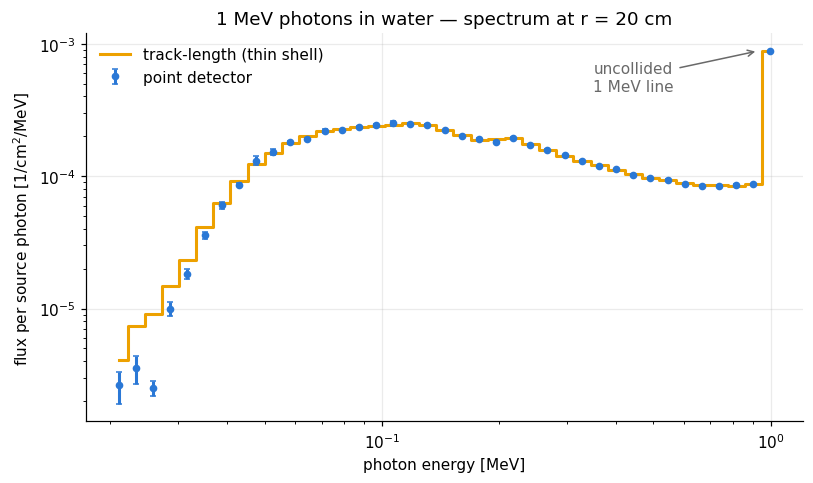

In [4]:
e_mid = 0.5 * (e_bins[1:] + e_bins[:-1]) / 1e6
de = np.diff(e_bins) / 1e6  # MeV

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.step(e_mid, shell_mean / de, where='mid', color=C_REF,
        label='track-length (thin shell)')
ax.errorbar(e_mid, point_mean / de, yerr=point_std / de, color=C_POINT,
            ls='none', marker='o', ms=4, capsize=2, label='point detector')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('photon energy [MeV]')
ax.set_ylabel('flux per source photon [1/cm$^2$/MeV]')
ax.set_title('1 MeV photons in water — spectrum at r = 20 cm')
ax.annotate('uncollided\n1 MeV line', xy=(0.93, point_mean[-1]/de[-1]),
            xytext=(0.35, point_mean[-1]/de[-1]*0.5), color='dimgray',
            arrowprops=dict(arrowstyle='->', color='dimgray'))
ax.legend(frameon=False)
plt.tight_layout()

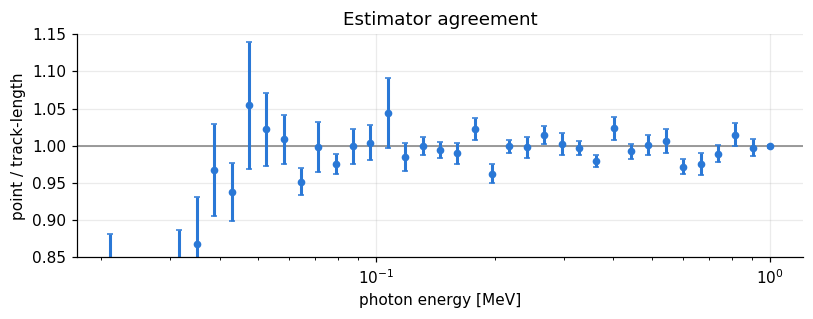

In [5]:
# agreement, bin by bin
ratio = np.divide(point_mean, shell_mean, out=np.full_like(point_mean, np.nan),
                  where=shell_mean > 0)
sigma = np.hypot(point_std, shell_std)
rel = np.divide(sigma, shell_mean, out=np.full_like(sigma, np.nan),
                where=shell_mean > 0)

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.axhline(1.0, color='gray', lw=1)
ax.errorbar(e_mid, ratio, yerr=rel, color=C_POINT, ls='none', marker='o',
            ms=4, capsize=2)
ax.set_xscale('log')
ax.set_ylim(0.85, 1.15)
ax.set_xlabel('photon energy [MeV]')
ax.set_ylabel('point / track-length')
ax.set_title('Estimator agreement')
plt.tight_layout()

## 3. High-Z, high-energy: pair production and the 511 keV annihilation line

6.5 MeV photons on a 5 cm iron sphere. Above 1.022 MeV pair production creates
electron–positron pairs; the positron annihilates into two 511 keV photons whose expected
contribution is scored isotropically at the annihilation site. Iron K-shell fluorescence
(~6.4 keV) is scored the same way.

We use `electron_treatment = 'led'` here. With the default thick-target bremsstrahlung
(`'ttb'`) model, bremsstrahlung photons are emitted *exactly along the electron direction* —
a delta distribution that a next-event estimator cannot score, so their first-flight
contribution would be missing (OpenMC prints a warning).

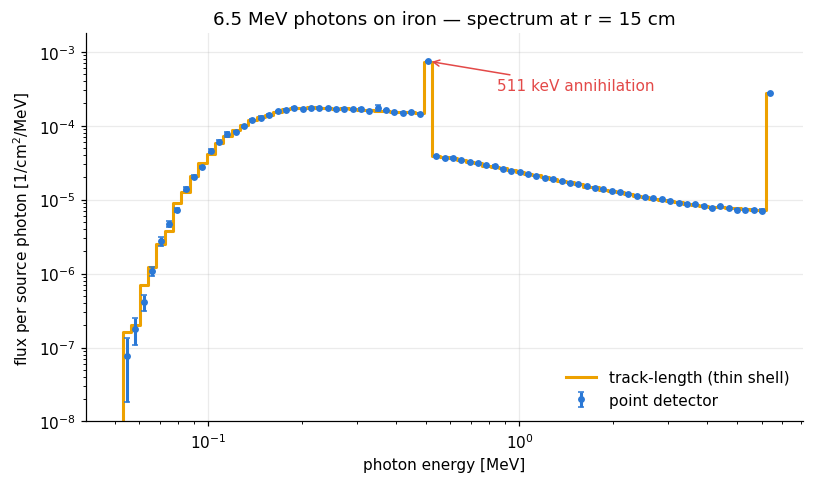

In [6]:
iron = openmc.Material(name='iron')
iron.add_element('Fe', 1.0)
iron.set_density('g/cm3', 7.874)

model = openmc.Model()
he = openmc.Material(name='trace2')
he.add_nuclide('He4', 1.0)
he.set_density('g/cm3', 1e-12)
model.materials = [iron, he]

sw = openmc.Sphere(r=5.0)
s1, s2 = openmc.Sphere(r=14.8), openmc.Sphere(r=15.2)
sout = openmc.Sphere(r=40.0, boundary_type='vacuum')
shell_cell = openmc.Cell(region=+s1 & -s2, fill=he)
model.geometry = openmc.Geometry([
    openmc.Cell(region=-sw, fill=iron),
    openmc.Cell(region=+sw & -s1, fill=he),
    shell_cell,
    openmc.Cell(region=+s2 & -sout, fill=he),
])
model.settings.source = openmc.IndependentSource(
    space=openmc.stats.Point((0., 0., 0.)),
    angle=openmc.stats.Isotropic(),
    energy=openmc.stats.Discrete([6.5e6], [1.0]),
    particle='photon',
)
model.settings.run_mode = 'fixed source'
model.settings.photon_transport = True
model.settings.electron_treatment = 'led'
model.settings.particles = 200_000
model.settings.batches = 10

e_bins_fe = np.logspace(np.log10(50e3), np.log10(6.6e6), 80)
ef = openmc.EnergyFilter(e_bins_fe)
part = openmc.ParticleFilter('photon')

t_point = openmc.Tally(name='point')
t_point.filters = [openmc.PointFilter([((15., 0., 0.), 0.5)]), part, ef]
t_point.scores = ['flux']
t_shell = openmc.Tally(name='shell')
t_shell.filters = [openmc.CellFilter([shell_cell]), part, ef]
t_shell.scores = ['flux']
model.tallies = [t_point, t_shell]

sp_path = model.run(cwd=workdir / 'iron', output=False)
shell_volume = 4/3 * math.pi * (15.2**3 - 14.8**3)
with openmc.StatePoint(sp_path) as sp:
    fe_point = sp.get_tally(name='point').mean.ravel()
    fe_point_std = sp.get_tally(name='point').std_dev.ravel()
    fe_shell = sp.get_tally(name='shell').mean.ravel() / shell_volume

e_mid_fe = 0.5 * (e_bins_fe[1:] + e_bins_fe[:-1]) / 1e6
de_fe = np.diff(e_bins_fe) / 1e6

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.step(e_mid_fe, fe_shell / de_fe, where='mid', color=C_REF,
        label='track-length (thin shell)')
ax.errorbar(e_mid_fe, fe_point / de_fe, yerr=fe_point_std / de_fe,
            color=C_POINT, ls='none', marker='o', ms=3.5, capsize=2,
            label='point detector')
i511 = np.searchsorted(e_bins_fe, 0.511e6) - 1
ax.annotate('511 keV annihilation', xy=(0.511, fe_point[i511]/de_fe[i511]),
            xytext=(0.85, 3e-4), color=C_ACCENT,
            arrowprops=dict(arrowstyle='->', color=C_ACCENT))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-8)
ax.set_xlabel('photon energy [MeV]')
ax.set_ylabel('flux per source photon [1/cm$^2$/MeV]')
ax.set_title('6.5 MeV photons on iron — spectrum at r = 15 cm')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()

## 4. Coupled neutron–photon: photons born in neutron reactions

Point detectors also score photons at their production site in neutron collisions
(e.g. hydrogen capture's 2.22 MeV line, oxygen inelastic gammas), using the reaction
product's angle–energy distribution. A single tally with a `ParticleFilter` for both
species gives the neutron *and* photon point flux.

In [7]:
model, shell_cell = sphere_model(source_particle='neutron', source_E=2.0e6)
model.settings.particles = 100_000
model.settings.batches = 10

part_np = openmc.ParticleFilter(['neutron', 'photon'])
t_point = openmc.Tally(name='point')
t_point.filters = [openmc.PointFilter([((20., 0., 0.), 0.5)]), part_np]
t_point.scores = ['flux']
t_shell = openmc.Tally(name='shell')
t_shell.filters = [openmc.CellFilter([shell_cell]), part_np]
t_shell.scores = ['flux']
model.tallies = [t_point, t_shell]

sp_path = model.run(cwd=workdir / 'coupled', output=False)
shell_volume = 4/3 * math.pi * (20.2**3 - 19.8**3)
with openmc.StatePoint(sp_path) as sp:
    pm = sp.get_tally(name='point').mean.ravel()
    ps = sp.get_tally(name='point').std_dev.ravel()
    sm = sp.get_tally(name='shell').mean.ravel() / shell_volume

print("2 MeV neutron source in water, detector at r = 20 cm")
print(f"{'':10} {'point detector':>16} {'track-length':>16} {'ratio':>8}")
for i, species in enumerate(['neutron', 'photon']):
    print(f"{species:10} {pm[i]:13.4e} +/- {ps[i]:7.1e} {sm[i]:13.4e} {pm[i]/sm[i]:8.4f}")

2 MeV neutron source in water, detector at r = 20 cm
             point detector     track-length    ratio
neutron       1.4410e-04 +/- 7.2e-07    1.4524e-04   0.9921
photon        6.8734e-05 +/- 1.6e-07    6.9074e-05   0.9951


## 5. Point detectors in CAD (DAGMC / `.h5m`) geometry

Point detectors work in DAGMC geometry too: the next-event ray is traced through the
triangle-mesh surfaces of the `.h5m` model to accumulate the optical depth to the detector,
exactly as in CSG geometry. This demo uses `nested_shell_geometry.h5m` (shipped next to this
notebook): nested chamfered cubes whose volumes are tagged `mat:void` / `mat:shell`, with the
outer boundary tagged `boundary:vacuum`. Materials are assigned by matching the OpenMC
material *name* to the `mat:` tag.

We fill the shells with iron, put a 1 MeV photon source at the center, and compare three
point detectors against a radial `SphericalMesh` track-length tally. Detector positions must
lie *inside* the DAGMC model boundary. This cell is skipped automatically if your OpenMC
build does not have DAGMC support (`openmc --version` shows `DAGMC support: yes/no`).

In [8]:
import openmc.lib

dagmc_ok = openmc.lib._dagmc_enabled()
h5m_file = Path('nested_shell_geometry.h5m')
if not dagmc_ok:
    print('OpenMC was built without DAGMC support -- skipping this demo.')
else:
    model = openmc.Model()

    iron = openmc.Material(name='shell')  # name must match the mat: tag
    iron.add_element('Fe', 1.0)
    iron.set_density('g/cm3', 2.0)
    model.materials = [iron]

    dag_univ = openmc.DAGMCUniverse(h5m_file)
    print('bounding box:', dag_univ.bounding_box)
    print('material tags:', dag_univ.material_names)
    model.geometry = openmc.Geometry(dag_univ)

    model.settings.source = openmc.IndependentSource(
        space=openmc.stats.Point((0., 0., 0.)),
        angle=openmc.stats.Isotropic(),
        energy=openmc.stats.Discrete([1.0e6], [1.0]),
        particle='photon',
    )
    model.settings.run_mode = 'fixed source'
    model.settings.photon_transport = True
    model.settings.electron_treatment = 'led'
    model.settings.particles = 50_000
    model.settings.batches = 10

    # radial track-length reference on a spherical mesh (1 cm bins)
    r_edges = np.arange(1.0, 89.0, 1.0)
    smesh = openmc.SphericalMesh(r_grid=r_edges)
    part = openmc.ParticleFilter('photon')
    t_mesh = openmc.Tally(name='radial')
    t_mesh.filters = [openmc.MeshFilter(smesh), part]
    t_mesh.scores = ['flux']

    # detectors at mesh-bin centers so the volume-average comparison is fair
    det_r = [8.5, 25.5, 60.5]
    pf = openmc.PointFilter([((r, 0., 0.), 1.0) for r in det_r])
    t_point = openmc.Tally(name='point')
    t_point.filters = [pf, part]
    t_point.scores = ['flux']
    model.tallies = [t_mesh, t_point]

    sp_path = model.run(cwd=workdir / 'dagmc', output=False)
    with openmc.StatePoint(sp_path) as sp:
        mesh_flux = (sp.get_tally(name='radial').mean.ravel()
                     / (4/3*math.pi*np.diff(r_edges**3)))
        dag_point = sp.get_tally(name='point').mean.ravel()
        dag_std = sp.get_tally(name='point').std_dev.ravel()

    print(f"\n{'r [cm]':>7} {'point detector':>16} {'mesh bin':>12} {'ratio':>7}")
    for r, pm, ps in zip(det_r, dag_point, dag_std):
        i = np.searchsorted(r_edges, r) - 1
        print(f"{r:7.1f} {pm:11.3e} +/- {ps/pm*100:3.0f}% {mesh_flux[i]:12.3e} "
              f"{pm/mesh_flux[i]:7.3f}")

bounding box: BoundingBox(lower_left=(-90.0, -90.0, -102.42640687119285), upper_right=(90.0, 90.0, 102.42640687119285))
material tags: ['shell', 'void']

 r [cm]   point detector     mesh bin   ratio
    8.5   1.284e-03 +/-   0%    1.284e-03   1.000
   25.5   1.050e-04 +/-   4%    1.067e-04   0.984
   60.5   9.275e-07 +/-  19%    1.118e-06   0.830



 r [cm]   point detector     mesh bin   ratio
    8.5   1.284e-03 +/-   0%    1.284e-03   1.000
   25.5   1.050e-04 +/-   4%    1.067e-04   0.984
   60.5   9.275e-07 +/-  19%    1.118e-06   0.830


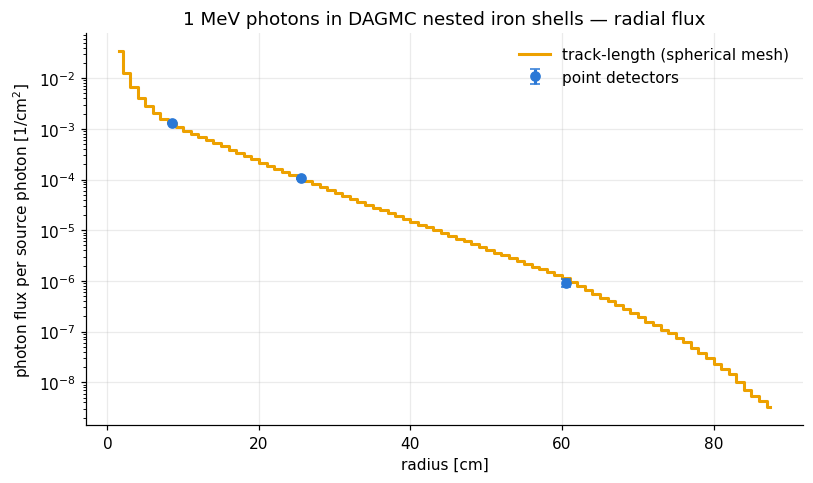

In [9]:
if dagmc_ok:
    r_mid = 0.5 * (r_edges[1:] + r_edges[:-1])
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.step(r_mid, mesh_flux, where='mid', color=C_REF,
            label='track-length (spherical mesh)')
    ax.errorbar(det_r, dag_point, yerr=dag_std, color=C_POINT, ls='none',
                marker='o', ms=6, capsize=3, label='point detectors', zorder=3)
    ax.set_yscale('log')
    ax.set_xlabel('radius [cm]')
    ax.set_ylabel('photon flux per source photon [1/cm$^2$]')
    ax.set_title('1 MeV photons in DAGMC nested iron shells — radial flux')
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    print('skipped (no DAGMC support)')

## Notes and caveats

- **Estimator**: tallies with a `PointFilter` automatically use the `next-event` estimator;
  they are compatible with `EnergyFilter`, `ParticleFilter`, and `TimeFilter`, but not with
  outgoing-energy/Legendre/surface filters or scores that require analog collisions
  (`current`, `pulse-height`, ...).
- **Exclusion radius `r0`**: for detectors inside a scattering medium, choose `r0` on the
  order of a fraction of a mean free path. Contributions from collisions within `r0` use a
  uniform-collision-density average; without it the $1/d^2$ tail makes the variance infinite.
- **Convergence in-medium**: like MCNP's F5, contributions from collisions just outside the
  exclusion sphere and near-forward coherent scattering make the tail of the score
  distribution heavy — expect slower, from-below convergence for detectors deep inside
  scattering media.
- **Bremsstrahlung (TTB)**: first-flight contributions of TTB photons cannot be scored
  (delta-function emission direction); results are underestimated where bremsstrahlung
  dominates. Use `'led'` or full agreement checks as above.
- **Boundary conditions**: point detectors require vacuum boundary conditions (no reflective
  or periodic surfaces) and continuous-energy mode.
- **Geometry**: CSG and DAGMC (`.h5m`) geometries are both supported — the detector rays are
  traced through whatever geometry the model uses. Detector positions must be inside the
  model boundary; a ray that exits the model before reaching the detector contributes
  nothing.